In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [39]:
df=pd.read_csv("1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

In [40]:
print(df.head(5))

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [41]:
print(df.tail(5))

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00            5.9       60000    Petrol   
298     city  2009           3.35           11.0       87934    Petrol   
299     city  2017          11.50           12.5        9000    Diesel   
300     brio  2016           5.30            5.9        5464    Petrol   

    Seller_Type Transmission  Owner  
296      Dealer       Manual      0  
297      Dealer       Manual      0  
298      Dealer       Manual      0  
299      Dealer       Manual      0  
300      Dealer       Manual      0  


In [42]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [61]:
print(" Total Number of rows and columns",df.shape)

 Total Number of rows and columns (299, 9)


In [44]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [45]:
print("Missing value",df.isnull().sum())

Missing value Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [46]:
print("\n Duplicate Rows:",df.duplicated().sum())


 Duplicate Rows: 2


In [47]:
df=df.drop_duplicates()

In [48]:
print("Statistical summary",df.describe())

Statistical summary               Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   299.000000     299.000000     299.000000     299.000000  299.000000
mean   2013.615385       4.589632       7.541037   36916.752508    0.043478
std       2.896868       4.984240       8.567887   39015.170352    0.248720
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.850000       1.200000   15000.000000    0.000000
50%    2014.000000       3.510000       6.100000   32000.000000    0.000000
75%    2016.000000       6.000000       9.840000   48883.500000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [49]:
# Select numerical columns
numeric_cols = ['Year', 'Selling_Price', 'Present_Price', 
                'Kms_Driven', 'Owner']

# Check outliers using IQR method
for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"\n{col}: {len(outliers)} outliers")


Year: 7 outliers

Selling_Price: 16 outliers

Present_Price: 14 outliers

Kms_Driven: 8 outliers

Owner: 11 outliers


# EDA

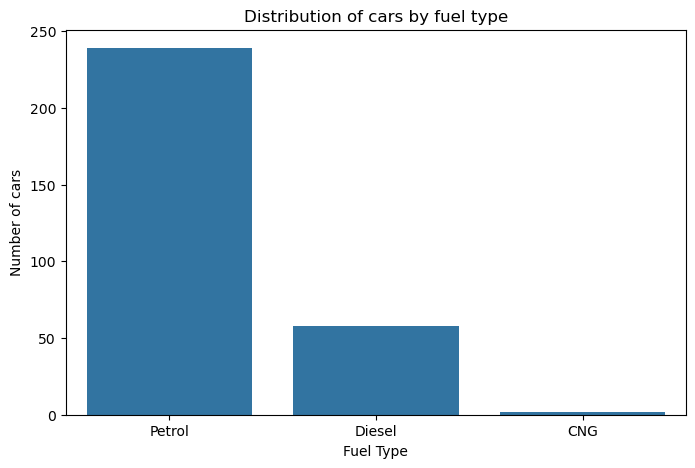

In [51]:
# Fuel Type Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Fuel_Type")
plt.title("Distribution of cars by fuel type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of cars")
plt.show()

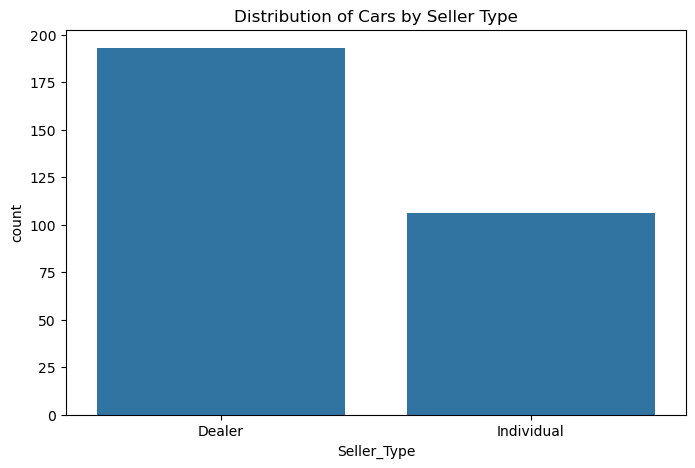

In [52]:
# Seller Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Seller_Type")
plt.title("Distribution of Cars by Seller Type")
plt.show()

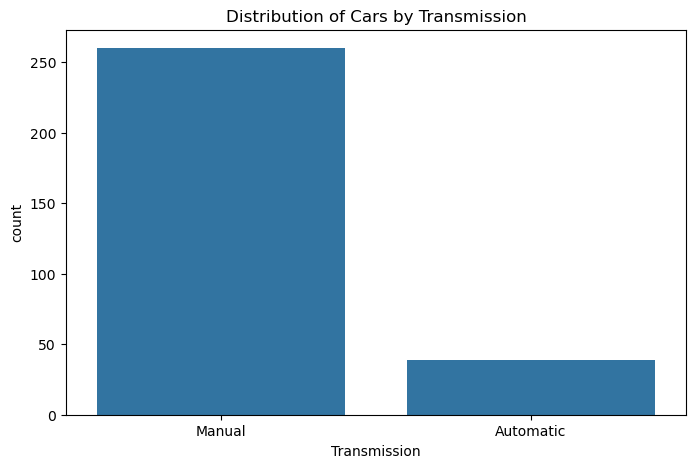

In [53]:
# Transmission Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Transmission")
plt.title("Distribution of Cars by Transmission")
plt.show()

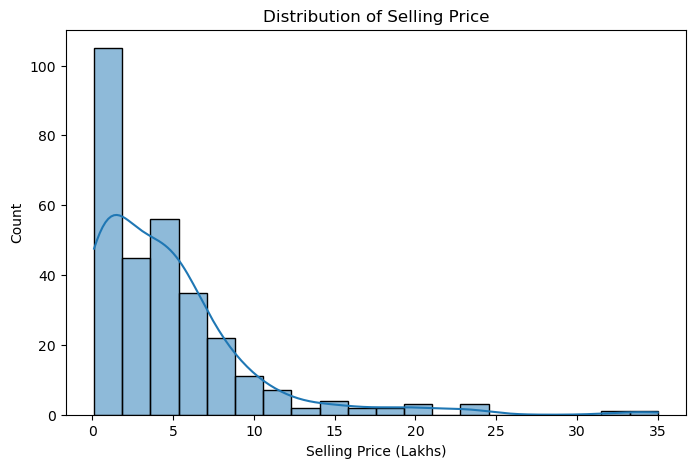

In [54]:
# Selling Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], bins=20, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.show()

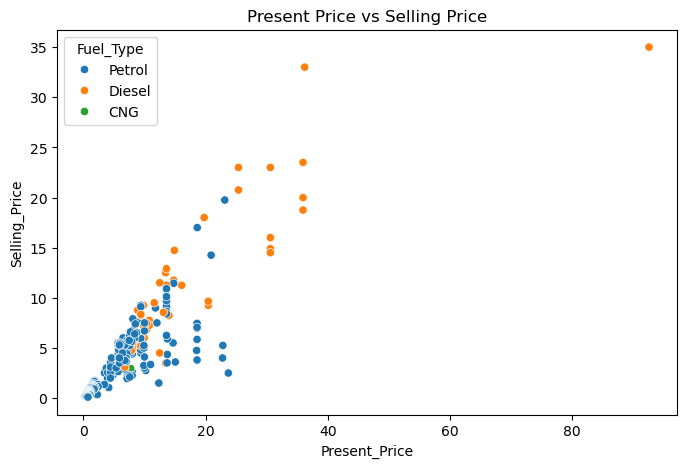

In [55]:
#  Present Price vs Selling Price
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price",
    hue="Fuel_Type"
)
plt.title("Present Price vs Selling Price")
plt.show()


Average Selling Price by Fuel Type:
Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


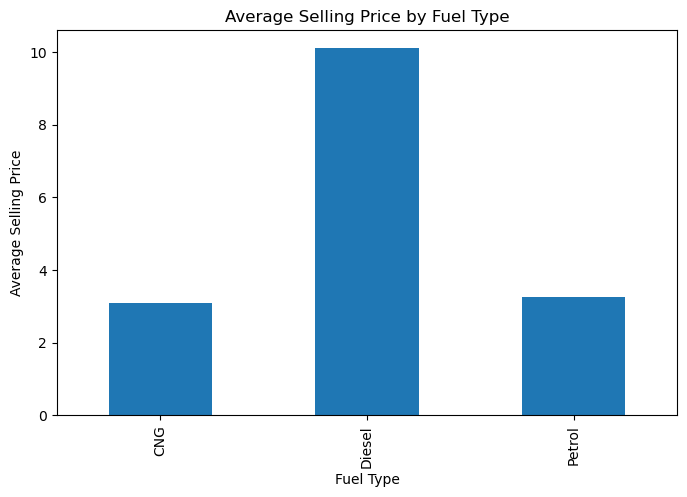

In [56]:
# Average Selling Price by Fuel Type
fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean()

print("\nAverage Selling Price by Fuel Type:")
print(fuel_price)

plt.figure(figsize=(8, 5))
fuel_price.plot(kind="bar")
plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.show()


Average Selling Price by Transmission:
Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


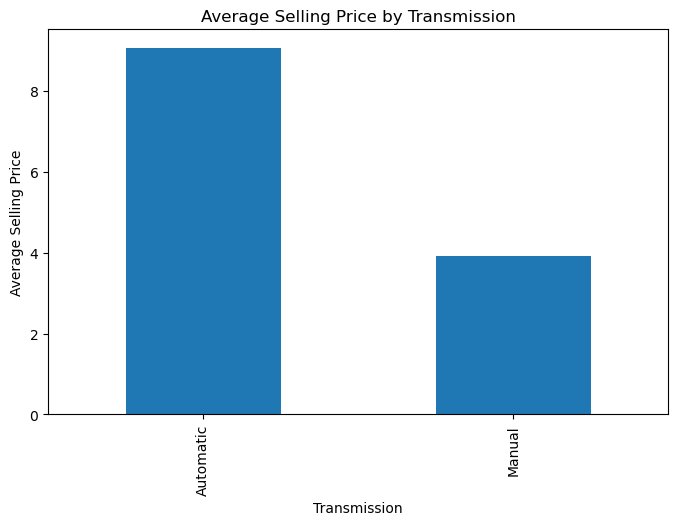

In [57]:
#  Average Selling Price by Transmission
transmission_price = df.groupby("Transmission")["Selling_Price"].mean()

print("\nAverage Selling Price by Transmission:")
print(transmission_price)

plt.figure(figsize=(8, 5))
transmission_price.plot(kind="bar")
plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")
plt.show()

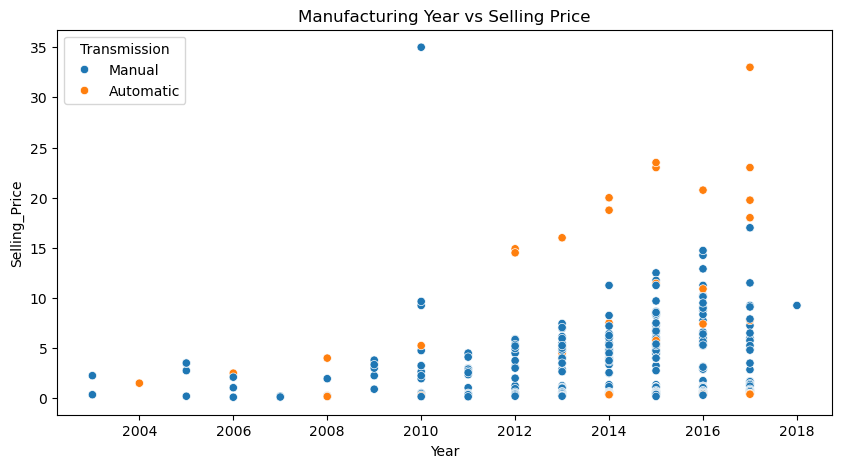

In [58]:
#  Relationship Between Manufacturing Year and Selling Price
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price",
    hue="Transmission"
)
plt.title("Manufacturing Year vs Selling Price")
plt.show()


Correlation Matrix:
                   Year  Selling_Price  Present_Price  Kms_Driven     Owner
Year           1.000000       0.234369      -0.053563   -0.525714 -0.181639
Selling_Price  0.234369       1.000000       0.876378    0.028566 -0.087880
Present_Price -0.053563       0.876378       1.000000    0.205253  0.009947
Kms_Driven    -0.525714       0.028566       0.205253    1.000000  0.089367
Owner         -0.181639      -0.087880       0.009947    0.089367  1.000000


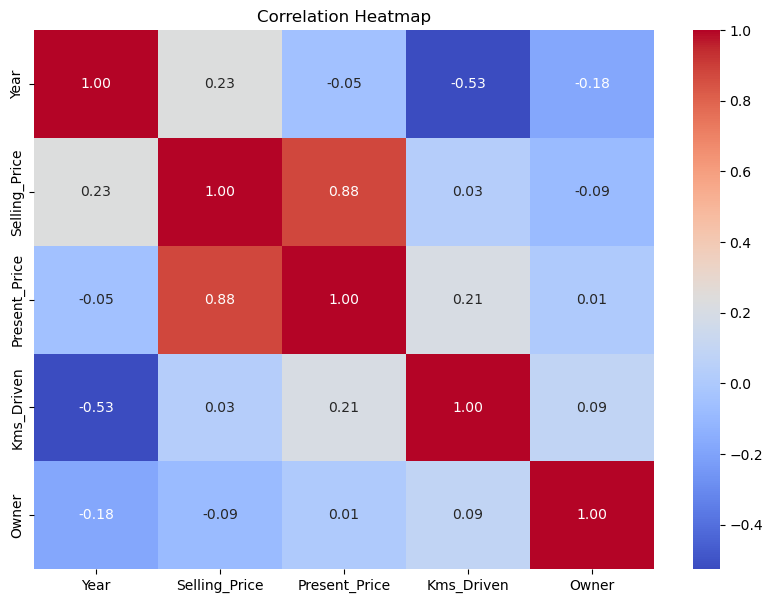

In [59]:
#  Correlation Analysis
numeric_df = df.select_dtypes(include=np.number)

print("\nCorrelation Matrix:")
print(numeric_df.corr())

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [60]:
#  Key Findings
print("\n KEY INSIGHTS ")

print("Average Selling Price:", 
      round(df["Selling_Price"].mean(), 2))

print("Median Selling Price:", 
      round(df["Selling_Price"].median(), 2))

print("\nMost Common Fuel Type:")
print(df["Fuel_Type"].mode()[0])

print("\nMost Common Seller Type:")
print(df["Seller_Type"].mode()[0])

print("\nMost Common Transmission:")
print(df["Transmission"].mode()[0])

print("\nMost Common Car:")
print(df["Car_Name"].mode()[0])

print("\nHighest Average Selling Price by Fuel Type:")
print(fuel_price.idxmax())

print("\nCorrelation with Selling Price:")
print(
    numeric_df.corr()["Selling_Price"]
    .sort_values(ascending=False)
)


========== KEY INSIGHTS ==========
Average Selling Price: 4.59
Median Selling Price: 3.51

Most Common Fuel Type:
Petrol

Most Common Seller Type:
Dealer

Most Common Transmission:
Manual

Most Common Car:
city

Highest Average Selling Price by Fuel Type:
Diesel

Correlation with Selling Price:
Selling_Price    1.000000
Present_Price    0.876378
Year             0.234369
Kms_Driven       0.028566
Owner           -0.087880
Name: Selling_Price, dtype: float64
